In [1]:
# Visualization for every embedding, 2d or 3d
import pandas as pd
import seaborn as sn
from glob import glob
import pylab as plt
import numpy as np

import sys
sys.path.append('../../')
import MHMDS.embed_funs as emb

In [2]:
myclorseq = ['#f90e11','#ff7a0d','#ffb508','#f7ef04',
            '#d9f167','#b9f395','#92f5ba','#5af6d9',
            '#11e9f4','#4bd3f5','#61bcf6','#70a3f7',
            '#7986f7','#7d65f7','#5410f2','#9d07e1',
            '#cf0bd0','#f819be','#cb0f9f','#9f0c76']

In [3]:
# for each dataset, load metadata and the embeddings
dataset_names_2d = ['ToggleSwitch','Krumsiek11','Paul_PCA100','Olsson_PCA100',
                 'Celegans_10k_PCA100','Celegans_40k_PCA100']
method_2d = ['M-HMDS','PHATE','DiffMap','t-sne','umap','PCA','ForceAtlas2','PoincareMap']

In [4]:
def load_2d(dataset):
    
    comp_dir = '../../Competing-Methods/EmbeddingCoords/'
    # poincaremap
    poincaremap = np.loadtxt(glob(comp_dir+'%s/%s*'
                                  %(dataset,dataset))[0],delimiter=',')
    poincaremap = emb.to_native(poincaremap)

    # PHATE
    phate2 = np.loadtxt(glob(comp_dir+'%s/phatemat*nd_2*'%dataset)[0])

    # ForceAtlas2
    forceatlas2 = np.loadtxt(glob(comp_dir+'%s/ForceAtlas2*nd_2*'
                            %dataset)[0])

    # umap
    umap2 = np.loadtxt(glob(comp_dir+'%s/umap*nd_2*'%dataset)[0])

    # t-sne
    tsne = np.loadtxt(glob(comp_dir+'%s/t-sne*nd_2*'%dataset)[0])

    # DiffMap
    diffmap2 = np.loadtxt(glob(comp_dir+'%s/DiffMap*nd_2*'%dataset)[0])

    # PCA
    pca2 = np.loadtxt(glob(comp_dir+'%s/PCA*nd_2*'%dataset)[0])

    # m-hmds
    mhmds2 = np.loadtxt(glob('../../MultiscalehMDS_feature/result/FeatMat_%s/benchmark/cls*Nd_2*coords*'%dataset)[0])
    inds = np.loadtxt(glob('../../MultiscalehMDS_feature/result/FeatMat_%s/benchmark/cls*Nd_2*inds*'%dataset)[0])
    mhmds2 = mhmds2[np.argsort(inds)]
    mhmds2 = emb.to_native(mhmds2)
    
    return [mhmds2,phate2,diffmap2,tsne,umap2,pca2,forceatlas2,poincaremap]

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_40958/1317614376.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_40958/1317614376.py:40: UserWarning: The palette list has more values (20) than needed (16), which may not be intended.
  sn.scatterplot(data=df_toplot[np.isin(df_toplot['cell.type'],ctsub)],x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_40958/1317614376.py:40: UserWarning: The palette list has more values (20) than needed (16), which may not be intended.
  sn.scatterplot(data=df_toplot[np.isin(df_toplot['cell.type'],ctsub)],x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
/var/folders/x4/m6

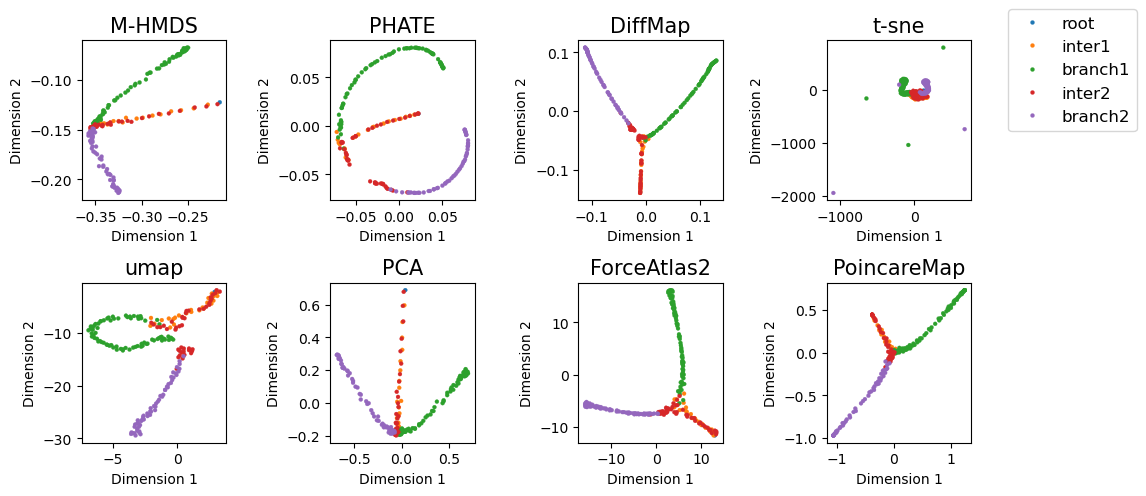

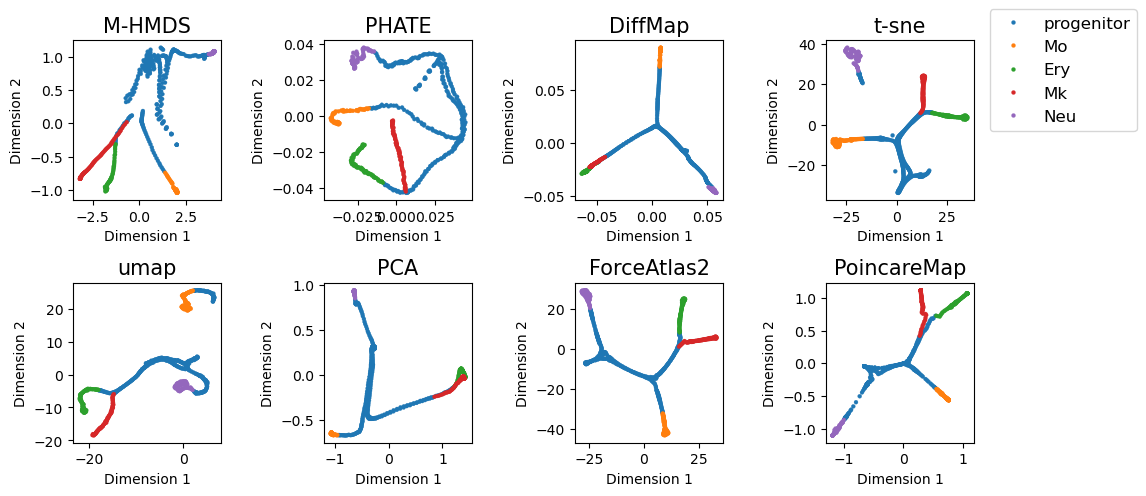

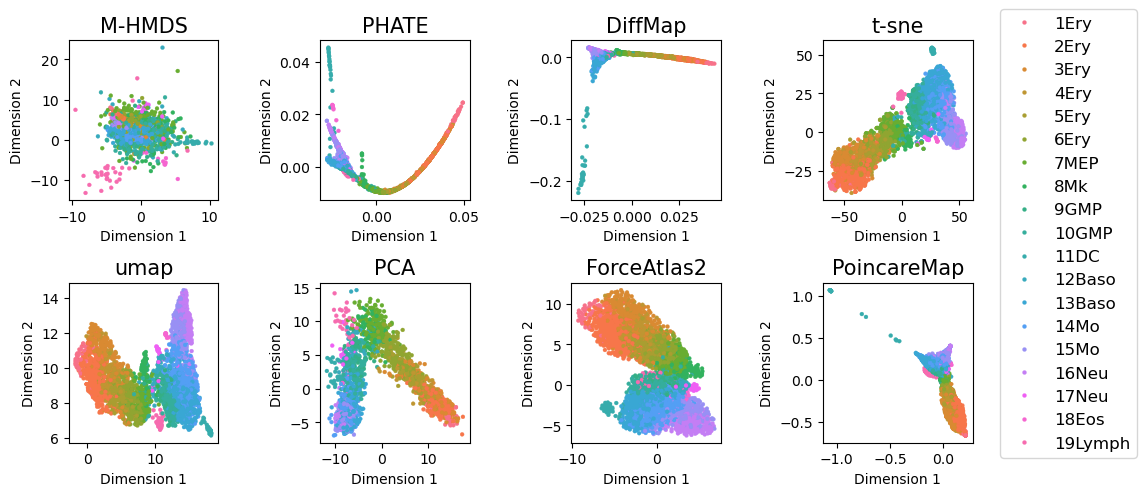

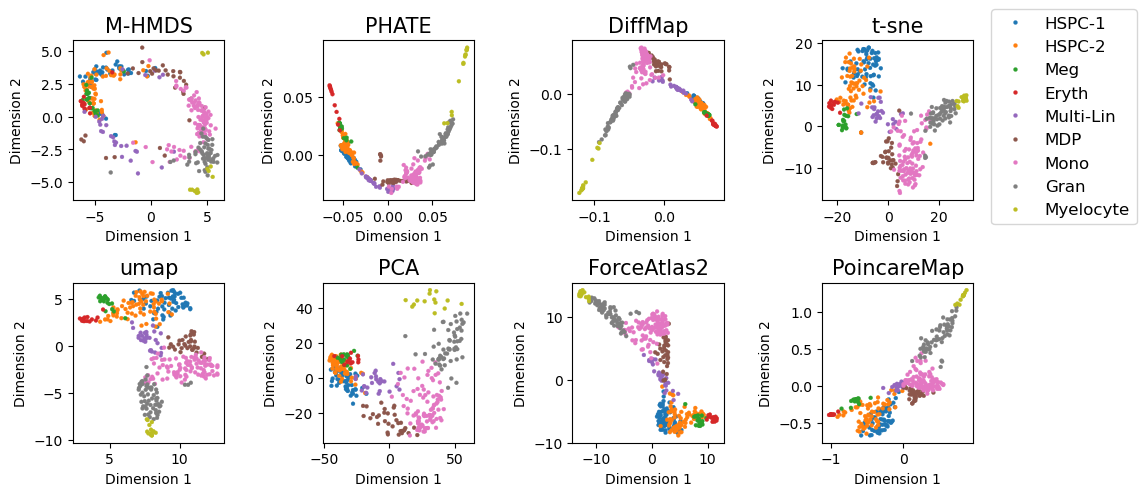

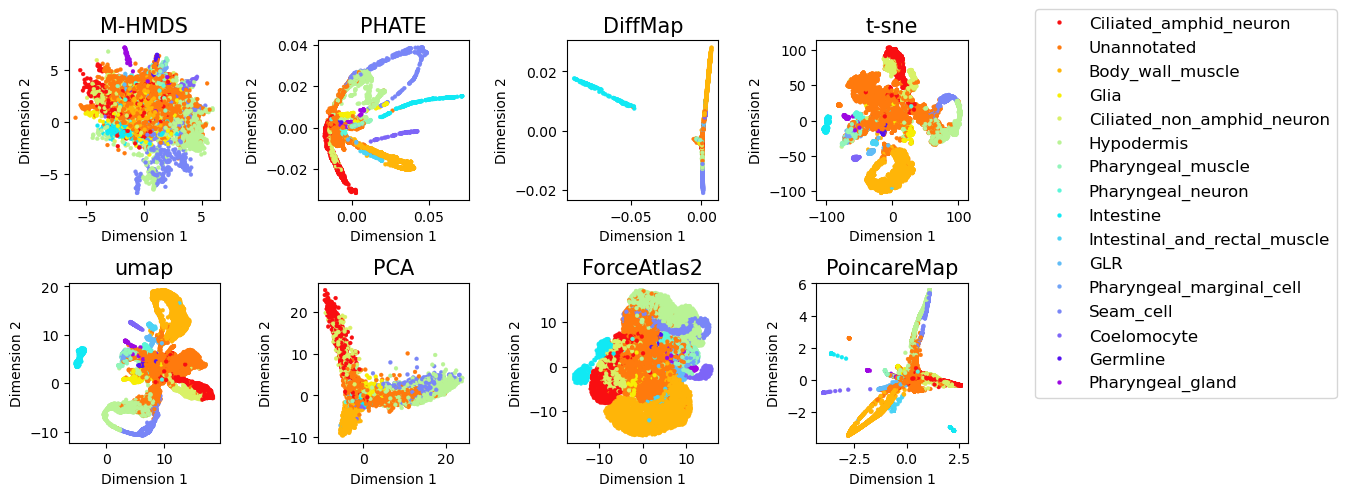

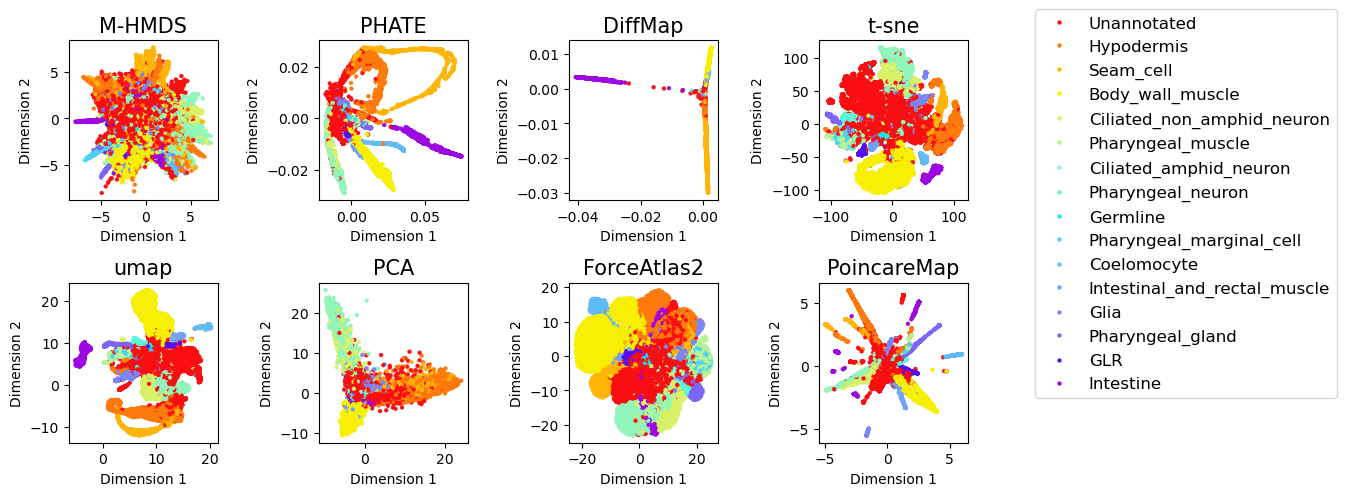

In [5]:
for i in range(len(dataset_names_2d)):
    dataset = dataset_names_2d[i]
    
    # plot 2-d visualization
    mats = load_2d(dataset)
    
    if dataset == 'Paul_PCA100':
        dataset = 'Paul'
    metadata = pd.read_csv('../../data/metadata/%s_metadata.csv'%dataset,index_col=0)
    fig,axs = plt.subplots(2,4,figsize=(10,5))
    axs = axs.flatten()
#     print(metadata.columns)
    
    
    if i<=3:
            toplot = metadata.columns[0]
    else:
            toplot = metadata.columns[0]
            metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'
            # cell types: regroup
            ctsub = metadata.groupby(
                'cell.type').count().iloc[:,1].sort_values(
                ascending=False)[:16].index
    if i == 2:
        labels = np.unique(metadata[toplot])
        ords = np.concatenate([labels[10:],labels[:10]])

    for j in range(8):
        df_toplot = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(mats[j],columns=['x','y'])],axis=1)
        if i in [0,1,3]:
            sn.scatterplot(data=df_toplot,x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
                      s=8)
        elif i == 2:
            sn.scatterplot(data=df_toplot,x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
                      s=8,hue_order=ords)
        else:
#             sn.scatterplot(data=df_toplot,x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
#                       s=8,palette = 'Spectral')
            sn.scatterplot(data=df_toplot[np.isin(df_toplot['cell.type'],ctsub)],x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
                      s=8,palette=myclorseq)
            
        axs[j].legend([],[], frameon=False)
        axs[j].set_title(method_2d[j],fontsize=15)
        axs[j].set_xlabel('Dimension 1',fontsize=10)
        axs[j].set_ylabel('Dimension 2',fontsize=10)
    handles, labels = axs[0].get_legend_handles_labels()
    if i<=3:
        fig.legend(handles, labels, loc='upper right',
                   bbox_to_anchor=(1.15, 1),fontsize=12)
    else:
        fig.legend(handles, labels, loc='upper right',
                   bbox_to_anchor=(1.35, 1),fontsize=12)

    fig.subplots_adjust(right=0.2) 
    plt.tight_layout()
    

/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_40958/1033892969.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_40958/1033892969.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_40958/1033892969.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'
/var/folders/x4

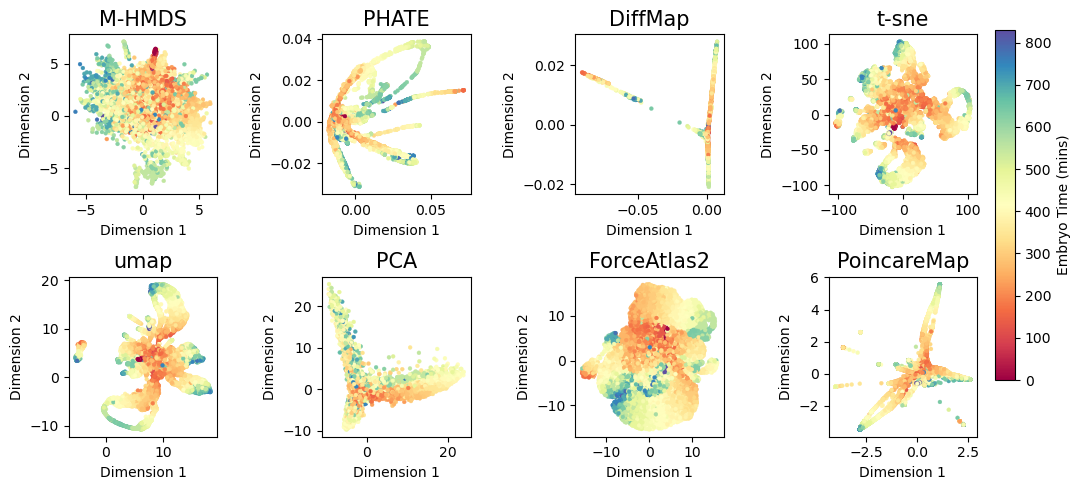

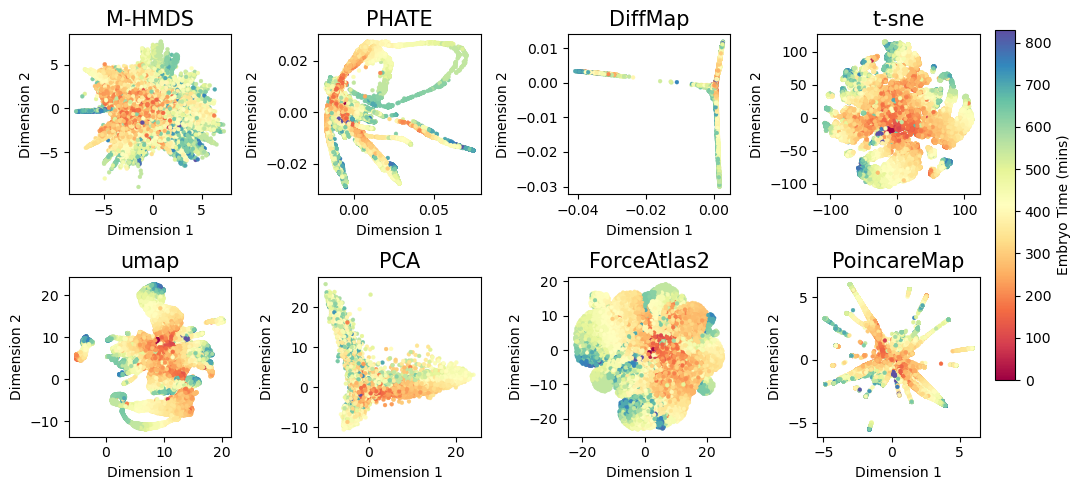

In [6]:
for i in [4,5]:
    dataset = dataset_names_2d[i]
    metadata = pd.read_csv('../../data/metadata/%s_metadata.csv'%dataset,index_col=0)

    # plot 2-d visualization
    mats = load_2d(dataset)
    fig,axs = plt.subplots(2,4,figsize=(10,5))
    axs = axs.flatten()
#     print(metadata.columns)
    
    
    if i<=3:
            toplot = metadata.columns[0]
    else:
            toplot = metadata.columns[1]
            metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'
            # cell types: regroup
            ctsub = metadata.groupby(
                'cell.type').count().iloc[:,1].sort_values(
                ascending=False)[:16].index
    if i == 2:
        labels = np.unique(metadata[toplot])
        ords = np.concatenate([labels[10:],labels[:10]])

    for j in range(8):
        df_toplot = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(mats[j],columns=['x','y'])],axis=1)
        if i in [0,1,3]:
            sn.scatterplot(data=df_toplot,x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
                      s=8)
        elif i == 2:
            sn.scatterplot(data=df_toplot,x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
                      s=8,hue_order=ords)
        else:
            sn.scatterplot(data=df_toplot,x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
                      s=8,palette = 'Spectral')
#             sn.scatterplot(data=df_toplot[np.isin(df_toplot['cell.type'],ctsub)],x='x',y='y',hue=toplot,ax=axs[j],edgecolor=None,
#                       s=8,palette=myclorseq)
            
        axs[j].legend([],[], frameon=False)
        axs[j].set_title(method_2d[j],fontsize=15)
        axs[j].set_xlabel('Dimension 1',fontsize=10)
        axs[j].set_ylabel('Dimension 2',fontsize=10)

    norm = plt.Normalize(df_toplot[toplot].min(), df_toplot[toplot].max())
    cmap = sn.color_palette('Spectral', as_cmap=True)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cax = fig.add_axes([axs[3].get_position().x1+0.1, axs[3].get_position().y0-0.3, 0.02, 
                        axs[3].get_position().height*2])
    cbar = plt.colorbar(sm, cax=cax)
    
    cbar.set_label('Embryo Time (mins)',fontsize=10)


    plt.tight_layout()



In [7]:
method_3d = ['M-HMDS','PHATE','DiffMap','umap','PCA']
dataset_names_3d = ['Krumsiek11','Paul_PCA100','Olsson_PCA100',
                 'Celegans_10k_PCA100','Celegans_40k_PCA100']

In [8]:
def load_3d(dataset,native):
    comp_dir = '../../Competing-Methods/EmbeddingCoords/'
    # methods
    # PHATE
    phate3 = np.loadtxt(glob(comp_dir+'%s/phatemat*nd_3*'%dataset)[0])

    umap3 = np.loadtxt(glob(comp_dir+'%s/umap*nd_3*'%dataset)[0])

    diffmap3 = np.loadtxt(glob(comp_dir+'%s/DiffMap*nd_3*'%dataset)[0])

    pca3 = np.loadtxt(glob(comp_dir+'%s/PCA*nd_3*'%dataset)[0])

    mhmds3 = np.loadtxt(glob('../../MultiscalehMDS_feature/result/FeatMat_%s/benchmark/cls*Nd_3*coords*'%dataset)[0])
    inds = np.loadtxt(glob('../../MultiscalehMDS_feature/result/FeatMat_%s/benchmark/cls*Nd_3*inds*'%dataset)[0])
    mhmds3 = mhmds3[np.argsort(inds)]
    if native == True:
        mhmds3 = emb.to_native(mhmds3)
    
    return [mhmds3,phate3,diffmap3,umap3,pca3]

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.colors as colors

In [ ]:
# cetegorical data
for i in range(len(dataset_names_3d)):
# for i in [0]:
    dataset = dataset_names_3d[i]
    
    # plot 3-d visualization
    mats = load_3d(dataset,native=True)
    
    
    if dataset == 'Paul_PCA100':
        dataset = 'Paul'
    metadata = pd.read_csv('../../data/metadata/%s_metadata.csv'%dataset,index_col=0)
    
    fig = make_subplots(
    rows=2, cols=3,
    specs=[[{'type': 'scatter3d'}]*3]*2,
    subplot_titles=method_3d+[''],
    horizontal_spacing=0.,
    vertical_spacing=0.1)

#     print(metadata.columns)
    
    if i<=2:
            toplot = metadata.columns[0]
    else:
            toplot = metadata.columns[0]
            metadata['cell.type'][pd.isna(metadata['cell.type'])]='Unannotated'
            # cell types: regroup
            ctsub = metadata.groupby(
                'cell.type').count().iloc[:,1].sort_values(
                ascending=False)[:16].index
    
    for j in range(5):
        df_toplot = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(mats[j],columns=['x','y','z'])],axis=1)
        if i > 2:
            df_toplot = df_toplot[np.isin(df_toplot[toplot],ctsub)]
        labels = np.unique(df_toplot[toplot])
        if i ==1: 
            labels = np.concatenate([labels[10:],labels[:10]])
        show = True if j ==0 else False 
        skip = len(myclorseq)//len(labels)
        for kk in range(len(labels)):
            cat = labels[kk]
            fig.add_trace(go.Scatter3d(
                x=df_toplot['x'][df_toplot[toplot]==cat],
                y=df_toplot['y'][df_toplot[toplot]==cat],
                z=df_toplot['z'][df_toplot[toplot]==cat],
                mode='markers',
                showlegend=show,
                name=cat,
                marker=dict(
                    size=2,
                    color=myclorseq[kk*skip],   
                    opacity=1.0,

                )),
            row=j//3+1, col=j%3+1)
    fig.update_layout(
    autosize=False,
    width=1400,
    height=800,
    )
    fig.update_layout(legend= {'itemsizing': 'constant'})
#     fig.update_scenes(xaxis_tickfont_size=6,
#                      yaxis_tickfont_size=6,
#                      zaxis_tickfont_size=6)
    fig.show()
#     fig.write_html('%s_3d.html'%dataset)
            


In [ ]:
# continuous data
# for i in range(len(dataset_names_3d)):
for i in [3,4]:
    dataset = dataset_names_3d[i]
   
    # plot 3-d visualization
    mats = load_3d(dataset,native=True)

    metadata = pd.read_csv('../../data/metadata/%s_metadata.csv'%dataset,index_col=0)
    
    fig = make_subplots(
    rows=2, cols=3,
    specs=[[{'type': 'scatter3d'}]*3]*2,
    subplot_titles=method_3d+[''],
    horizontal_spacing=0.,
    vertical_spacing=0.1)

#     print(metadata.columns)
    
    if i<=2:
            toplot = metadata.columns[0]
    else:
            toplot = metadata.columns[1]
            # cell types: regroup
            ctsub = metadata.groupby(
                'cell.type').count().iloc[:,1].sort_values(
                ascending=False)[:15].index
    
    for j in range(5):
        df_toplot = pd.concat([metadata.reset_index().iloc[:,1:],
                               pd.DataFrame(mats[j],columns=['x','y','z'])],axis=1)
        df_toplot['code'] = pd.Categorical(df_toplot[toplot]).codes
        fig.add_trace(go.Scatter3d(
            x=df_toplot['x'],
            y=df_toplot['y'],
            z=df_toplot['z'],
            mode='markers',
            showlegend=False,
            marker=dict(
                size=2,
                color=df_toplot[toplot],    # set color to an array/list of desired values
                colorscale='Spectral',   # choose a colorscale
                opacity=0.8,
                colorbar={"title": 'Embryo Time (mins)'}
                
            )),
        row=j//3+1, col=j%3+1)
    fig.update_layout(
    autosize=False,
    width=1400,
    height=800,
    )
#     fig.update_scenes(xaxis_tickfont_size=6,
#                      yaxis_tickfont_size=6,
#                      zaxis_tickfont_size=6)
    fig.show()
#     fig.write_html('%s_3d_embryotime.html'%dataset)
            
#     